<a href="https://colab.research.google.com/github/anitabudhiraja/DeepLearning/blob/main/practical_6_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning Techniques (DOAI250006)
## Institution: NIELIT ROPAR
## Practical 6: Image data augmentation using Keras

This notebook demonstrates how to artificially expand the size of a training dataset by creating modified versions of images in the dataset. This technique, called Data Augmentation, helps prevent overfitting and improves model generalization.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, datasets

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


### 1. Load a Sample Image
We will load the CIFAR-10 dataset just to extract a single image to demonstrate the augmentation effects.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


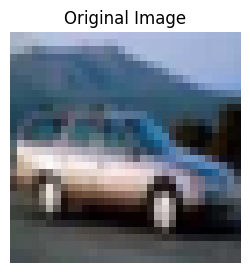

In [ ]:
# Load CIFAR-10 data
(train_images, train_labels), _ = datasets.cifar10.load_data()

# Select a single image (e.g., image index 4 is usually an automobile/frog)
sample_image = train_images[4]

# Display the original image
plt.figure(figsize=(3, 3))
plt.imshow(sample_image)
plt.title("Original Image")
plt.axis('off')
plt.show()

### 2. Define the Augmentation Pipeline
Using Keras preprocessing layers, we can build a sequential model that applies random transformations. This approach is highly efficient as it can run on the GPU during model training.

In [ ]:
# Define an augmentation pipeline
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"), # Randomly flip images
  layers.RandomRotation(0.2),                 # Randomly rotate by 20%
  layers.RandomZoom(0.2),                     # Randomly zoom in/out by 20%
  layers.RandomContrast(0.2)                  # Randomly adjust contrast
])

print("Data augmentation pipeline ready.")

Data augmentation pipeline ready.


### 3. Apply and Visualize the Augmentation
Data augmentation layers expect a batch of images as input (a 4D tensor). We will expand the dimensions of our sample image, apply the pipeline, and visualize the randomized results.

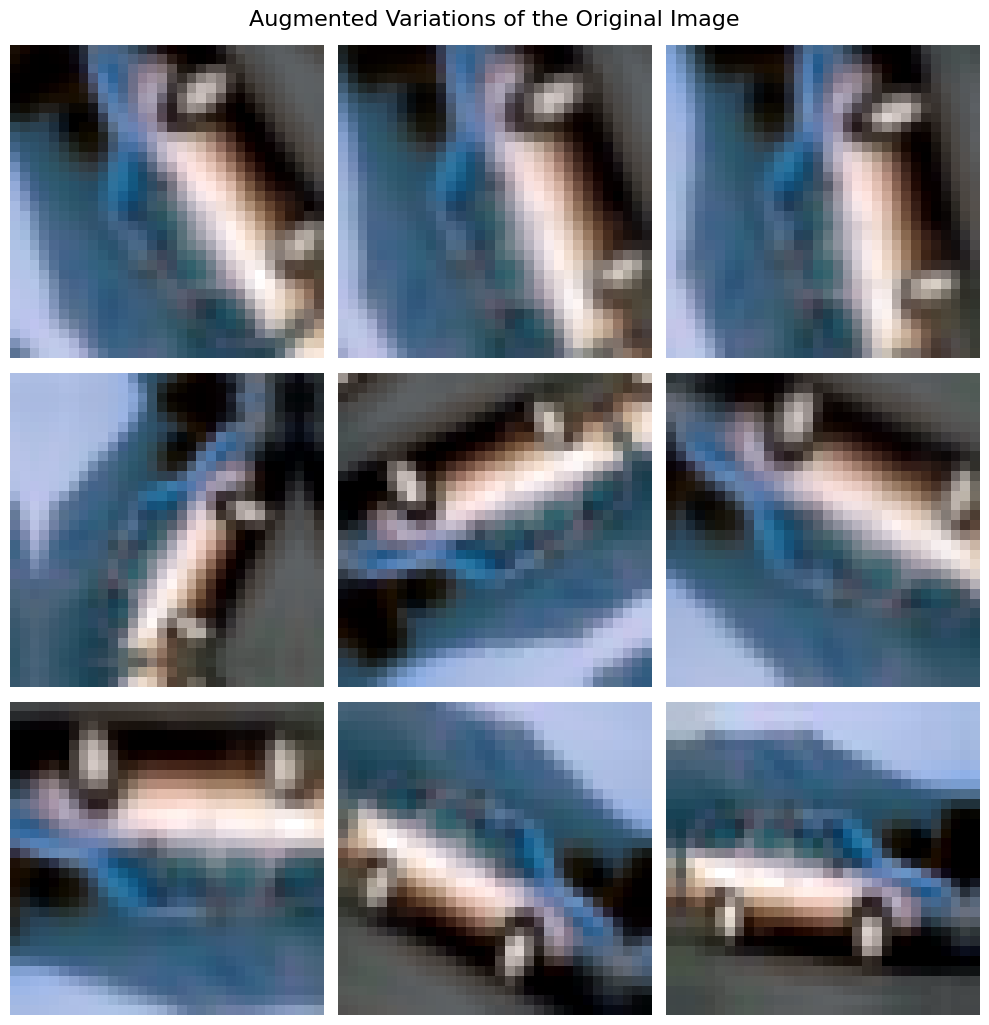

In [ ]:
# Add a batch dimension: shape becomes (1, 32, 32, 3)
image_batch = tf.expand_dims(sample_image, 0)

# Set up a figure to show 9 augmented variations
plt.figure(figsize=(10, 10))

for i in range(9):
  # Apply the augmentation pipeline
  # Note: training=True is required to activate the random layers
  augmented_image = data_augmentation(image_batch, training=True)

  plt.subplot(3, 3, i + 1)
  # Convert tensor to uint8 for proper visualization
  plt.imshow(tf.cast(augmented_image[0], tf.uint8))
  plt.axis("off")

plt.tight_layout()
plt.suptitle("Augmented Variations of the Original Image", y=1.02, fontsize=16)
plt.show()

### 4. Integration Example
In a real workflow, you would integrate this directly into your classification model like this:

```python
model = tf.keras.Sequential([
  data_augmentation,          # Augmentation happens here!
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  # ... rest of the model ...
])
```